In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

# Lecture 1: Introduction #

### Python can be used for basic math operations ###

It uses the same order of operations as calculators.

In [2]:
2 + 3

5

### It can also be used for more advanced operations. 
We can input entire texts to analyze using the code below. 

In [3]:
# Read two books, fast!

huck_finn_url = 'https://www.inferentialthinking.com/data/huck_finn.txt'
huck_finn_text = read_url(huck_finn_url)
huck_finn_chapters = huck_finn_text.split('CHAPTER ')[44:]

little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]

### Displaying the chapters as it was inputted is not very easy to look at or understand. ###

In [4]:
huck_finn_chapters

['I. YOU don\'t know about me without you have read a book by the name of The Adventures of Tom Sawyer; but that ain\'t no matter. That book was made by Mr. Mark Twain, and he told the truth, mainly. There was things which he stretched, but mainly he told the truth. That is nothing. I never seen anybody but lied one time or another, without it was Aunt Polly, or the widow, or maybe Mary. Aunt Polly--Tom\'s Aunt Polly, she is--and Mary, and the Widow Douglas is all told about in that book, which is mostly a true book, with some stretchers, as I said before. Now the way that the book winds up is this: Tom and me found the money that the robbers hid in the cave, and it made us rich. We got six thousand dollars apiece--all gold. It was an awful sight of money when it was piled up. Well, Judge Thatcher he took it and put it out at interest, and it fetched us a dollar a day apiece all the year round--more than a body could tell what to do with. The Widow Douglas she took me for her son, and 

### The first step in displaying any data is organizing it in a way that it easy to read and interpret.

In [5]:
Table().with_column('Chapters', huck_finn_chapters)

Chapters
I. YOU don't know about me without you have read a book ...
II. WE went tiptoeing along a path amongst the trees bac ...
"III. WELL, I got a good going-over in the morning from o ..."
"IV. WELL, three or four months run along, and it was wel ..."
V. I had shut the door to. Then I turned around and ther ...
"VI. WELL, pretty soon the old man was up and around agai ..."
"VII. ""GIT up! What you 'bout?"" I opened my eyes and look ..."
VIII. THE sun was up so high when I waked that I judged ...
IX. I wanted to go and look at a place right about the m ...
X. AFTER breakfast I wanted to talk about the dead man a ...


### Now that it is organized, we can start to ask questions and analyze the data as we would like to ###
First let's see how often individual character names appear. 

In [6]:
np.char.count(huck_finn_chapters, 'Tom')

array([ 6, 24,  5,  0,  0,  0,  2,  2,  0,  0,  2,  3,  1,  0,  0,  0,  3,
        5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  4, 19, 15,
       14, 18,  9, 32, 11, 11,  8, 30,  6])

In [7]:
np.char.count(huck_finn_chapters, 'Jim')

array([ 0, 16,  0,  8,  0,  0,  0, 22, 11, 19,  4, 20,  9,  6, 16, 28,  0,
       10, 13, 18,  1,  0,  9,  5,  0,  0,  0,  1,  3,  5, 17,  0,  5, 17,
       18, 23,  4, 27, 10, 13,  0, 12,  6])

In [8]:
np.char.count(huck_finn_chapters, 'Huck')

array([ 3,  2,  2,  1,  0,  2,  0,  5,  1,  0,  4,  0,  0,  5,  7, 10,  0,
        1,  0,  1,  0,  0,  7,  1,  0,  0,  0,  0,  0,  0,  2,  0,  0,  4,
        8,  1,  0,  2,  0,  3,  0,  2,  4])

### Remember organization is key when displaying data. 
Which is easier to read?
The data display above or in the table below?

In [9]:
# Make a Table of Counts for each Character
counts = Table().with_columns([
    'Tom', np.char.count(huck_finn_chapters, 'Tom'),
    'Jim', np.char.count(huck_finn_chapters, 'Jim'),
    'Huck', np.char.count(huck_finn_chapters, 'Huck'),
])

# Make a table of cummulative counts for each character
cumulative_counts = Table()
for label in counts.labels:
    cumulative_counts = cumulative_counts.with_column(label, np.cumsum(counts.column(label)))
cumulative_counts

Tom,Jim,Huck
6,0,3
30,16,5
35,16,7
35,24,8
35,24,8
35,24,10
37,24,10
39,46,15
39,57,16
39,76,16


### Data in tables can easily be displayed in graphical form.

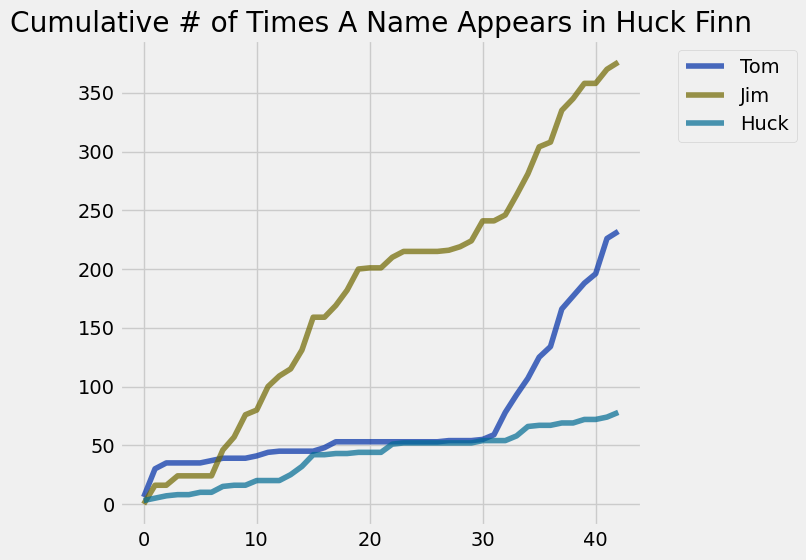

In [11]:
# Plot the cumulative counts using a line chart:
# how many times in Chapter 1, how many times in Chapters 1 and 2, and so on.


cumulative_counts.plot()
plots.title('Cumulative # of Times A Name Appears in Huck Finn')
plots.show()

### Interpreting Data is a key component of Data Science. 
***QUESTION: What interesting observations could be made from looking at the graph above?***
    
***QUESTION: What questions could you ask? List as many as you can think of.***


### Let's do the same thing with another classic book - "Little Women"
We already inputted the text in the first cell of this notebook. 


In [12]:
# The chapters of Little Women

Table().with_column('Chapters', little_women_chapters)

Chapters
"ONE PLAYING PILGRIMS ""Christmas won't be Christmas witho ..."
TWO A MERRY CHRISTMAS Jo was the first to wake in the gr ...
"THREE THE LAURENCE BOY ""Jo! Jo! Where are you?"" cried Me ..."
"FOUR BURDENS ""Oh, dear, how hard it does seem to take up ..."
"FIVE BEING NEIGHBORLY ""What in the world are you going t ..."
SIX BETH FINDS THE PALACE BEAUTIFUL The big house did pr ...
"SEVEN AMY'S VALLEY OF HUMILIATION ""That boy is a perfect ..."
"EIGHT JO MEETS APOLLYON ""Girls, where are you going?"" as ..."
"NINE MEG GOES TO VANITY FAIR ""I do think it was the most ..."
"TEN THE P.C. AND P.O. As spring came on, a new set of am ..."


In [13]:
# Counts of names in the chapters of Little Women
"""
Docstring that can do

multiple lines
"""
names = ['Amy', 'Beth', 'Jo', 'Laurie', 'Meg']
mentions = {name: np.char.count(little_women_chapters, name) for name in names}

counts = Table().with_columns([
        'Amy', mentions['Amy'],
        'Beth', mentions['Beth'],
        'Jo', mentions['Jo'],
        'Laurie', mentions['Laurie'],
        'Meg', mentions['Meg']
    ])
counts

Amy,Beth,Jo,Laurie,Meg
23,26,44,0,26
13,12,21,0,20
2,2,62,16,36
14,18,34,0,17
6,14,55,35,13
6,28,13,9,5
27,5,9,7,5
48,9,71,17,16
3,5,21,24,71
5,5,12,4,4


In [14]:
# Plot the cumulative counts using a line chart.

cumulative_counts = Table()
for label in counts.labels:
    cumulative_counts = cumulative_counts.with_column(label, np.cumsum(counts.column(label)))
cumulative_counts

Amy,Beth,Jo,Laurie,Meg
23,26,44,0,26
36,38,65,0,46
38,40,127,16,82
52,58,161,16,99
58,72,216,51,112
64,100,229,60,117
91,105,238,67,122
139,114,309,84,138
142,119,330,108,209
147,124,342,112,213


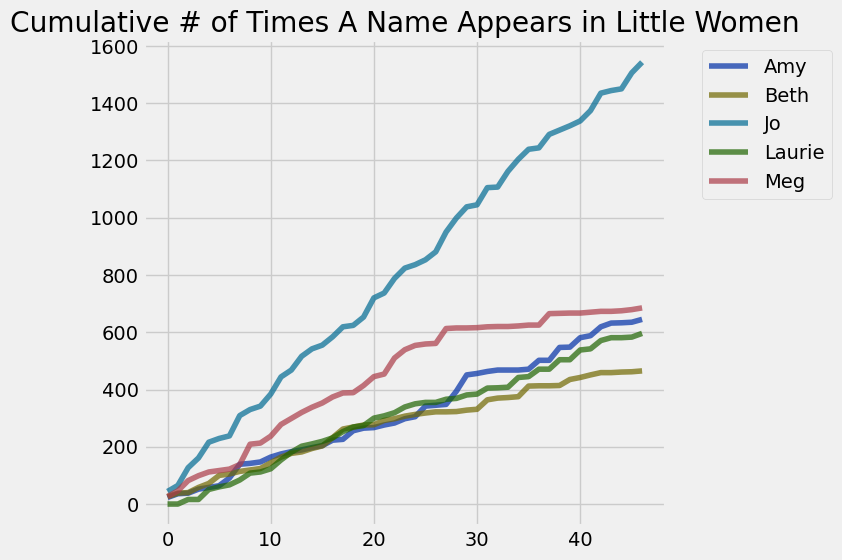

In [15]:
cumulative_counts.plot()
plots.title('Cumulative # of Times A Name Appears in Little Women')
plots.show()

### Interpreting Data is a key component of Data Science. 
***QUESTION: What interesting observations could be made from looking at the graph above?***
    
***QUESTION: What questions could you ask? List as many as you can think of.***

### Understanding Cumulative Totals ###

In [16]:
# Cumulutative Total
total = 0
for x in range(10):
    print(f"total = {total} + {x}")
    total = total + x

print(f"total = {total}")

total = 0 + 0
total = 0 + 1
total = 1 + 2
total = 3 + 3
total = 6 + 4
total = 10 + 5
total = 15 + 6
total = 21 + 7
total = 28 + 8
total = 36 + 9
total = 45


### The Length Command ###

In [17]:
len('Data 8')

6

In [18]:
len(read_url(huck_finn_url))

588035

### Data Analysis sometimes consist of comparing data. 
Let's compare the length and number of periods in each chapter of both books.

In [19]:
# In each chapter, count the number of all characters;
# call this the "length" of the chapter.
# Also count the number of periods.

length_hf = Table().with_columns([
        'Length', [len(s) for s in huck_finn_chapters],
        'Periods', np.char.count(huck_finn_chapters, '.')
    ])
length_lw = Table().with_columns([
        'Length', [len(s) for s in little_women_chapters],
        'Periods', np.char.count(little_women_chapters, '.')
    ])

In [20]:
# The counts for Huckleberry Finn

length_hf

Length,Periods
7026,66
11982,117
8529,72
6799,84
8166,91
14550,125
13218,127
22208,249
8081,71
7036,70


In [21]:
# The counts for Little Women

length_lw

Length,Periods
21759,189
22148,188
20558,231
25526,195
23395,255
14622,140
14431,131
22476,214
33767,337
18508,185


### Compare the tables using a Scatterplot ###
Each plot is a coordinate pair $(x,y)$ that represents one row in the table. </br>
The $x$ position represents the value from the horizontal axis. </br>
The $y$ position represents the value from the vertical axis.</br>
***QUESTION: Looking at the code, can you tell which color will represent each book?***

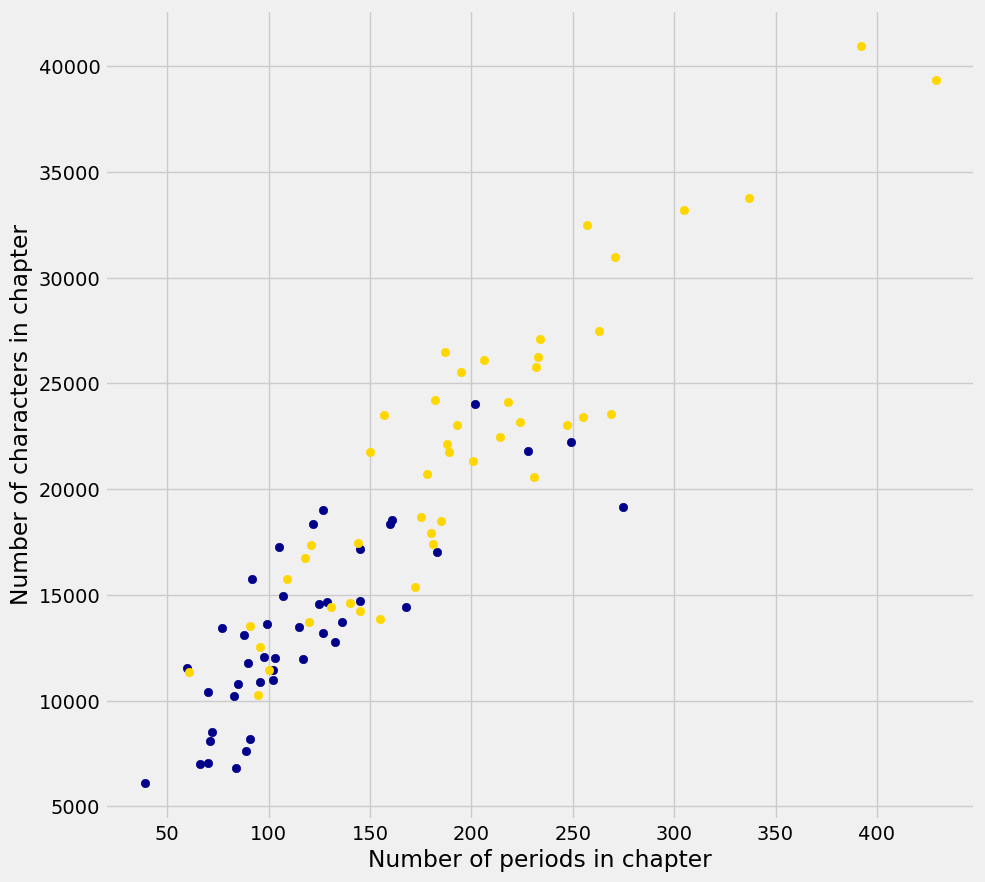

In [22]:
plots.figure(figsize=(10,10))
plots.scatter(length_hf[1], length_hf[0], color='darkblue')
plots.scatter(length_lw[1], length_lw[0], color='gold')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');

### Interpreting Data is a key component of Data Science. 
***QUESTION: What interesting observations could be made from looking at the graph above?***
    
***QUESTION: What questions could you ask? List as many as you can think of.***